In [1]:
#!/usr/bin/env python3
"""
CSE284 Final Project: PLINK vs KING for Relative Finding
Analysis notebook - compare relatedness estimates from both tools.

Run this after generating:
  - results/all_samples_ibd.genome (PLINK --genome output)
  - results/king_related_full.kin0 (KING --related output)
  - ~/ps2-wi26/sample_populations.txt (population metadata)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import time
import subprocess

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

# --- Load population metadata ---
pop_file = os.path.expanduser("~/ps2-wi26/sample_populations.txt")
pop_df = pd.read_csv(pop_file, sep=r'\s+', header=None, names=["ID", "Population"])
pop_map = dict(zip(pop_df["ID"], pop_df["Population"]))
print(f"Population metadata: {len(pop_map)} samples")
print(f"Populations: {pop_df['Population'].value_counts().to_dict()}")

# --- Load PLINK .genome output ---
plink_file = "results/all_samples_ibd.genome"
plink_df = pd.read_csv(plink_file, sep=r'\s+')
plink_df["pair"] = plink_df.apply(
    lambda r: tuple(sorted([r["IID1"], r["IID2"]])), axis=1
)
# Add population info
plink_df["Pop1"] = plink_df["IID1"].map(pop_map)
plink_df["Pop2"] = plink_df["IID2"].map(pop_map)
plink_df["SamePop"] = plink_df["Pop1"] == plink_df["Pop2"]
print(f"\nPLINK: {len(plink_df)} pairs loaded")

# --- Load KING .kin0 output ---
king_file = "results/king_related_full.kin0"
king_df = pd.read_csv(king_file, sep='\t')
king_df["pair"] = king_df.apply(
    lambda r: tuple(sorted([r["ID1"], r["ID2"]])), axis=1
)
king_df["Pop1"] = king_df["ID1"].map(pop_map)
king_df["Pop2"] = king_df["ID2"].map(pop_map)
king_df["SamePop"] = king_df["Pop1"] == king_df["Pop2"]
print(f"KING:  {len(king_df)} pairs loaded (kinship >= 0.0884)")

Population metadata: 857 samples
Populations: {'GWD': 280, 'CEU': 184, 'PUR': 150, 'PEL': 130, 'ASW': 113}

PLINK: 106491 pairs loaded
KING:  950 pairs loaded (kinship >= 0.0884)


In [3]:

# ============================================================
# 2. CLASSIFY RELATIONSHIPS
# ============================================================

def classify_plink(row):
    """Classify relationship from PLINK Z0, Z1, Z2 values."""
    z0, z1, z2, pi_hat = row["Z0"], row["Z1"], row["Z2"], row["PI_HAT"]
    if pi_hat > 0.9:
        return "MZ Twin/Duplicate"
    elif z1 > 0.9:
        return "Parent-Child"
    elif z1 > 0.4 and z1 < 0.6 and z0 < 0.3:
        return "Full Sibling"
    elif z2 < 0.1 and z1 > 0.4 and z1 < 0.6:
        return "2nd Degree"
    elif z2 < 0.1 and z1 > 0.15 and z1 < 0.35:
        return "3rd Degree"
    elif pi_hat > 0.4:
        return "1st Degree (other)"
    elif pi_hat > 0.15:
        return "Possibly Related"
    else:
        return "Unrelated"

def classify_king(row):
    """Classify relationship from KING kinship coefficient."""
    k = row["Kinship"]
    if k > 0.354:
        return "MZ Twin/Duplicate"
    elif k > 0.177:
        return "1st Degree"
    elif k > 0.0884:
        return "2nd Degree"
    elif k > 0.0442:
        return "3rd Degree"
    else:
        return "Unrelated"

plink_df["Relationship_PLINK"] = plink_df.apply(classify_plink, axis=1)
king_df["Relationship_KING"] = king_df.apply(classify_king, axis=1)

print("\n=== PLINK Relationship Classification ===")
print(plink_df["Relationship_PLINK"].value_counts())

print("\n=== KING Relationship Classification ===")
print(king_df["Relationship_KING"].value_counts())



=== PLINK Relationship Classification ===
Unrelated             58561
Possibly Related      29851
3rd Degree            17378
2nd Degree              652
1st Degree (other)       45
Parent-Child              4
Name: Relationship_PLINK, dtype: int64

=== KING Relationship Classification ===
3rd Degree    689
Unrelated     184
2nd Degree     72
1st Degree      5
Name: Relationship_KING, dtype: int64


In [4]:

# ============================================================
# 3. COMPARE: MERGE PLINK AND KING RESULTS
# ============================================================

# Get PLINK pairs that are at least "Possibly Related"
plink_related = plink_df[plink_df["Relationship_PLINK"] != "Unrelated"].copy()
king_related = king_df.copy()  # KING already filtered to kinship >= 0.0884

# Merge on pair
merged = pd.merge(
    plink_related[["pair", "IID1", "IID2", "Z0", "Z1", "Z2", "PI_HAT",
                    "Relationship_PLINK", "Pop1", "Pop2", "SamePop"]],
    king_related[["pair", "Kinship", "IBS0", "Relationship_KING"]],
    on="pair",
    how="outer",
    indicator=True
)

print("\n=== Overlap Analysis ===")
print(f"Pairs found by PLINK only:  {(merged['_merge'] == 'left_only').sum()}")
print(f"Pairs found by KING only:   {(merged['_merge'] == 'right_only').sum()}")
print(f"Pairs found by both:        {(merged['_merge'] == 'both').sum()}")

# For pairs found by both, compare classifications
both = merged[merged["_merge"] == "both"]
print(f"\n=== Agreement on shared pairs ({len(both)} pairs) ===")
if len(both) > 0:
    # Show the top related pairs from both tools
    print("\nTop related pairs (sorted by KING kinship):")
    top_pairs = both.sort_values("Kinship", ascending=False).head(20)
    print(top_pairs[["IID1", "IID2", "PI_HAT", "Kinship",
                      "Relationship_PLINK", "Relationship_KING",
                      "Pop1", "Pop2"]].to_string(index=False))



=== Overlap Analysis ===
Pairs found by PLINK only:  46984
Pairs found by KING only:   4
Pairs found by both:        946

=== Agreement on shared pairs (946 pairs) ===

Top related pairs (sorted by KING kinship):
   IID1    IID2  PI_HAT  Kinship Relationship_PLINK Relationship_KING Pop1 Pop2
NA20320 NA20321  0.5238   0.2709 1st Degree (other)        1st Degree  ASW  ASW
NA20334 NA20355  0.4912   0.2596       Parent-Child        1st Degree  ASW  ASW
NA20317 NA20318  0.4843   0.2465       Parent-Child        1st Degree  ASW  ASW
NA20359 NA20362  0.4864   0.2456       Parent-Child        1st Degree  ASW  ASW
NA19904 NA19913  0.4722   0.2443       Parent-Child        1st Degree  ASW  ASW
HG02464 HG02804  0.3410   0.1723   Possibly Related        2nd Degree  GWD  GWD
HG02610 HG02642  0.3750   0.1707   Possibly Related        2nd Degree  GWD  GWD
HG02624 HG02666  0.3318   0.1485   Possibly Related        2nd Degree  GWD  GWD
HG01067 HG01412  0.3487   0.1467   Possibly Related        2nd Deg

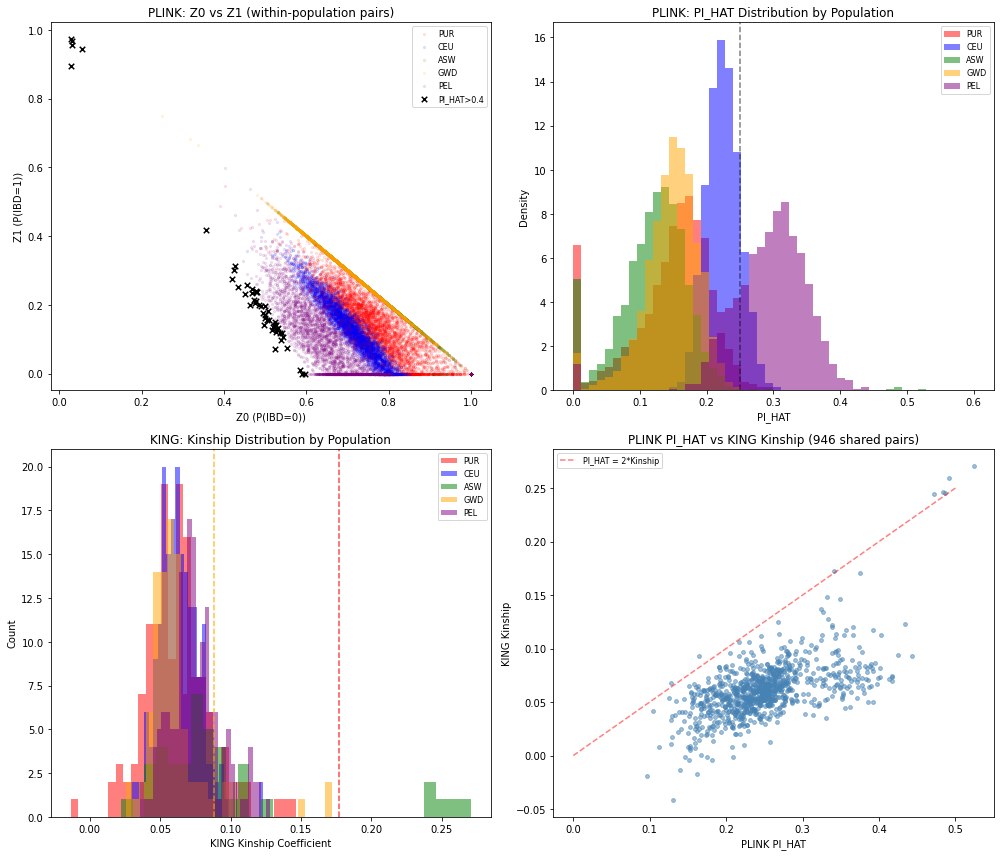


Saved: figures/plink_vs_king_comparison.png


In [5]:

# ============================================================
# 4. VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1: PLINK Z1 vs Z0 scatter ---
ax = axes[0, 0]
colors = {"PUR": "red", "CEU": "blue", "ASW": "green", "GWD": "orange", "PEL": "purple"}
for pop in colors:
    mask = plink_df["Pop1"] == pop
    subset = plink_df[mask & plink_df["SamePop"]]
    if len(subset) > 0:
        ax.scatter(subset["Z0"], subset["Z1"], alpha=0.1, s=5, c=colors[pop], label=pop)
# Highlight related pairs
related_mask = plink_df["PI_HAT"] > 0.4
if related_mask.sum() > 0:
    ax.scatter(plink_df.loc[related_mask, "Z0"],
               plink_df.loc[related_mask, "Z1"],
               c="black", s=30, zorder=5, marker="x", label="PI_HAT>0.4")
ax.set_xlabel("Z0 (P(IBD=0))")
ax.set_ylabel("Z1 (P(IBD=1))")
ax.set_title("PLINK: Z0 vs Z1 (within-population pairs)")
ax.legend(fontsize=8)

# --- Plot 2: PLINK PI_HAT distribution ---
ax = axes[0, 1]
for pop in colors:
    mask = (plink_df["Pop1"] == pop) & plink_df["SamePop"]
    subset = plink_df[mask]
    if len(subset) > 0:
        ax.hist(subset["PI_HAT"], bins=50, alpha=0.5, label=pop,
                color=colors[pop], density=True, range=(0, 0.6))
ax.set_xlabel("PI_HAT")
ax.set_ylabel("Density")
ax.set_title("PLINK: PI_HAT Distribution by Population")
ax.legend(fontsize=8)
ax.axvline(x=0.25, color="black", linestyle="--", alpha=0.5, label="1st degree threshold")

# --- Plot 3: KING kinship distribution ---
ax = axes[1, 0]
if len(king_df) > 0:
    for pop in colors:
        mask = (king_df["Pop1"] == pop) & king_df["SamePop"]
        subset = king_df[mask]
        if len(subset) > 0:
            ax.hist(subset["Kinship"], bins=30, alpha=0.5, label=pop, color=colors[pop])
    ax.set_xlabel("KING Kinship Coefficient")
    ax.set_ylabel("Count")
    ax.set_title("KING: Kinship Distribution by Population")
    ax.legend(fontsize=8)
    ax.axvline(x=0.177, color="red", linestyle="--", alpha=0.7, label="1st degree")
    ax.axvline(x=0.0884, color="orange", linestyle="--", alpha=0.7, label="2nd degree")

# --- Plot 4: PI_HAT vs KING Kinship for overlapping pairs ---
ax = axes[1, 1]
if len(both) > 0:
    ax.scatter(both["PI_HAT"], both["Kinship"], alpha=0.5, s=15, c="steelblue")
    ax.set_xlabel("PLINK PI_HAT")
    ax.set_ylabel("KING Kinship")
    ax.set_title(f"PLINK PI_HAT vs KING Kinship ({len(both)} shared pairs)")
    # Add diagonal reference
    ax.plot([0, 0.5], [0, 0.25], "r--", alpha=0.5, label="PI_HAT = 2*Kinship")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No overlapping pairs", ha="center", va="center",
            transform=ax.transAxes)

plt.tight_layout()
plt.savefig("figures/plink_vs_king_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: figures/plink_vs_king_comparison.png")


In [6]:

# ============================================================
# 5. POPULATION STRUCTURE EFFECT
# ============================================================

print("\n=== Population Structure Effect ===")
print("PLINK 'related' pairs (PI_HAT > 0.15) by population pair:")
pop_related = plink_df[plink_df["PI_HAT"] > 0.15].copy()
pop_related["PopPair"] = pop_related.apply(
    lambda r: "-".join(sorted([str(r["Pop1"]), str(r["Pop2"])])), axis=1
)
print(pop_related["PopPair"].value_counts().head(10))

print("\nKING related pairs by population pair:")
if len(king_df) > 0:
    king_df["PopPair"] = king_df.apply(
        lambda r: "-".join(sorted([str(r["Pop1"]), str(r["Pop2"])])), axis=1
    )
    print(king_df["PopPair"].value_counts().head(10))

print(f"\nKey insight: PLINK flags {len(pop_related)} pairs as related (PI_HAT > 0.15)")
print(f"KING flags only {len(king_df)} pairs as related (kinship > 0.0884)")
print("This difference is largely due to KING's robustness to population structure.")



=== Population Structure Effect ===
PLINK 'related' pairs (PI_HAT > 0.15) by population pair:
CEU-PUR    7925
PEL-PUR    5493
CEU-PEL    5420
CEU-CEU    4848
PEL-PEL    3518
GWD-GWD    3268
PUR-PUR    3080
ASW-GWD    1861
ASW-ASW     516
ASW-PUR     457
Name: PopPair, dtype: int64

KING related pairs by population pair:
CEU-CEU    195
CEU-PUR    162
PEL-PEL    155
PUR-PUR    137
GWD-GWD     90
PEL-PUR     55
ASW-PUR     43
ASW-ASW     40
ASW-GWD     34
CEU-PEL     19
Name: PopPair, dtype: int64

Key insight: PLINK flags 37046 pairs as related (PI_HAT > 0.15)
KING flags only 950 pairs as related (kinship > 0.0884)
This difference is largely due to KING's robustness to population structure.



=== Summary: Detected Relationships ===
                    PLINK  KING
1st Degree              0     5
1st Degree (other)     45     0
2nd Degree            652    72
3rd Degree          17378   689
Parent-Child            4     0
Possibly Related    29851     0
Unrelated           58561   184

=== Runtime Benchmarking (PS2 data, 462 samples) ===
PLINK --genome: 0.26 seconds
KING --related: 15.00 seconds


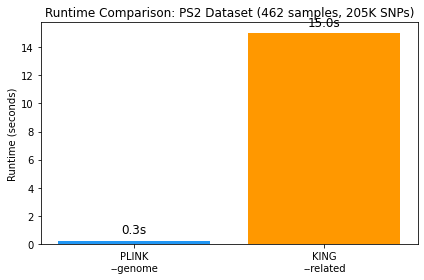

Saved: figures/runtime_comparison_ps2.png

=== Analysis Complete ===


In [7]:

# ============================================================
# 6. SUMMARY TABLE (like Group 17's results)
# ============================================================

print("\n=== Summary: Detected Relationships ===")
summary = pd.DataFrame({
    "PLINK": plink_df["Relationship_PLINK"].value_counts(),
    "KING": king_df["Relationship_KING"].value_counts()
}).fillna(0).astype(int)
print(summary)

# ============================================================
# 7. RUNTIME BENCHMARKING (PS2 dataset)
# ============================================================

print("\n=== Runtime Benchmarking (PS2 data, 462 samples) ===")

# PLINK timing
start = time.time()
subprocess.run(
    ["plink", "--bfile", os.path.expanduser("~/ps2-wi26/ps2_admixture.pruned"),
     "--genome", "--out", "results/benchmark_plink"],
    capture_output=True
)
plink_time = time.time() - start
print(f"PLINK --genome: {plink_time:.2f} seconds")

# KING timing
king_bin = os.path.expanduser("~/king")
start = time.time()
subprocess.run(
    [king_bin, "-b", os.path.expanduser("~/ps2-wi26/ps2_admixture.bed"),
     "--related", "--degree", "2", "--prefix", "results/benchmark_king"],
    capture_output=True
)
king_time = time.time() - start
print(f"KING --related: {king_time:.2f} seconds")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["PLINK\n--genome", "KING\n--related"], [plink_time, king_time],
              color=["#2196F3", "#FF9800"])
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Runtime Comparison: PS2 Dataset (462 samples, 205K SNPs)")
for bar, t in zip(bars, [plink_time, king_time]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{t:.1f}s", ha="center", fontsize=12)
plt.tight_layout()
plt.savefig("figures/runtime_comparison_ps2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/runtime_comparison_ps2.png")

print("\n=== Analysis Complete ===")